In [18]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

import numpy as np

## Task 1: Numerical differentiation

The definition of a derivative is
$  \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} $

Approximate **forward-difference:**
$  \frac{df}{dx} \approx \frac{f(x+h) - f(x)}{h} $


In [19]:
# 1. 
x = 1
h = np.logspace(-12,-1,base=10)

def f(x):
    return x**0.8

fd_vals = (f(x+h) - f(x))/h

print(f"Derivatives: {fd_vals}")

Derivatives: [0.80002671 0.80007583 0.79996333 0.79999546 0.80001341 0.80000359
 0.80000111 0.80000168 0.80000047 0.79999883 0.80000008 0.79999979
 0.80000006 0.79999994 0.79999998 0.79999999 0.79999997 0.80000001
 0.8        0.8        0.8        0.8        0.79999999 0.79999999
 0.79999998 0.79999997 0.79999995 0.79999991 0.79999985 0.79999974
 0.79999957 0.79999927 0.79999878 0.79999795 0.79999657 0.79999424
 0.79999035 0.79998381 0.79997286 0.79995449 0.7999237  0.79987209
 0.79978561 0.79964077 0.79939836 0.7989932  0.79831747 0.79719452
 0.79533931 0.79230345]


### 2. 

if $ f(x) = x^{0.8}$ 

then $ $ f'(x) = 0.8 x^{0.8-1}$ $ 
$ $ = f'(x) = 0.8 x^{-0.2} $ $ 

Then at x = 1,
$ $   f'(x)|_{x=1} = 0.8 \times 1^{-0.2} $ $ 

$ $ = 0.8$ $ 


In [20]:
# 2.  
exact_val = 0.8

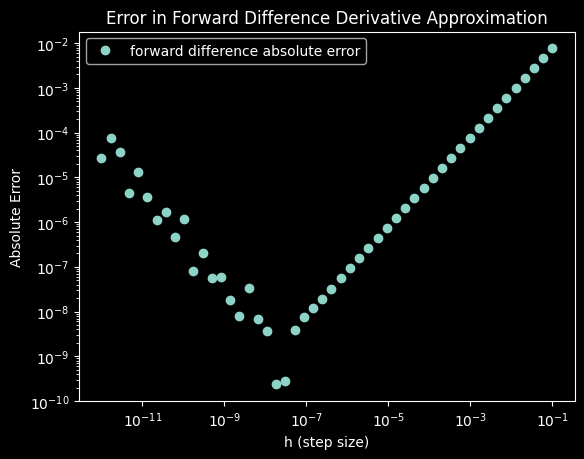

In [21]:
# 3.  

# We did absolute error in last Guide
# absolute error of your approximate values as a function of h on log-log scale.

abs_error = np.abs(fd_vals-exact_val)

plt.plot(h,abs_error,'o',label='forward difference absolute error')
plt.loglog()
plt.xlabel('h (step size)')
plt.ylabel('Absolute Error')
plt.title('Error in Forward Difference Derivative Approximation')
plt.legend()
plt.show()

### 4. 

At large h, the error decreases linearly (slope 1 on log-log) — this is **truncation error** from the O(h) term in the forward-difference approximation.

At small h (below 10^-8), the error increases again — this is **rounding error**. When h is tiny, f(x+h) and f(x) are nearly identical, so their difference loses significant digits (catastrophic cancellation). If f has a constant floating-point error episolon is almost 10^-16, the error in the derivative goes as elsilon/h, which grows as h goes to 0.

The optimal h balances both errors, around h $\approx$ sqrt(epsilon) $\approx$ 10^-8.

### 5. 

The general formula is:
$ f(x+h)=f(x)+hf^{\prime }(x)+\frac{h^{2}}{2!}f^{\prime \prime }(x)+\frac{h^{3}}{3!}f^{\prime \prime \prime }(x)+\cdots +\frac{h^{n}}{n!}f^{(n)}(x)+\cdots$               


Taylor expansions:
$  f(x+h) = f(x) + hf'(x) + \frac{h^2}{2}f''(x) + \frac{h^3}{6}f'''(x) + ... $ 
$  f(x-h) = f(x) - hf'(x) + \frac{h^2}{2}f''(x) - \frac{h^3}{6}f'''(x) + ... $ 

Subtracting the second from the first:
$  f(x+h) - f(x-h) = 2hf'(x) + \frac{2h^3}{6}f'''(x) + ... $ 

Now, what we have to do is, solve for $ f'(x)$ , putting it on the left side
$  f'(x) = \frac{f(x+h) - f(x-h)}{2h} - \frac{h^2}{6}f'''(x) + ... $ 

The extreme end factor on the right side is a function O of order $ h^2$ , we can write it as:
$  f'(x) \approx \frac{f(x+h) - f(x-h)}{2h} - O(h^2) $ 

$  f'(x) + O(h^2) \approx \frac{f(x+h) - f(x-h)}{2h} $ 

$ O(h^2)$  is the error factor, the difference between the central difference function and the f'(x). 

Note that: For small h values, this value should be negligible, at least that is what calculus tells us


Central Difference Values: [0.80002671 0.80004272 0.79998307 0.79999546 0.80000639 0.7999994
 0.80000111 0.80000168 0.80000047 0.79999936 0.80000008 0.79999979
 0.80000006 0.80000001 0.79999998 0.79999999 0.79999998 0.8
 0.8        0.8        0.8        0.8        0.8        0.8
 0.8        0.8        0.8        0.8        0.8        0.8
 0.8        0.8        0.8        0.8        0.8        0.8
 0.8        0.8        0.8        0.80000001 0.80000003 0.80000008
 0.80000023 0.80000065 0.80000182 0.80000512 0.8000144  0.80004049
 0.80011395 0.80032113]


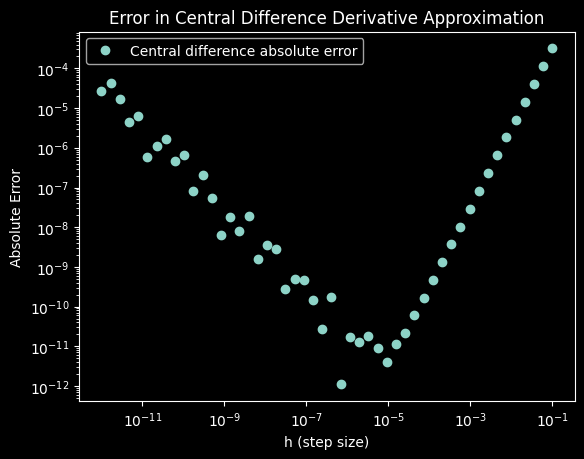

In [22]:
# 6.  

x = 1
h = np.logspace(-12,-1,base=10)

def f(x):
    return x**0.8

cd_vals = (f(x+h) - f(x-h))/ (2*h)

print(f"Central Difference Values: {cd_vals}")


# Error Plot


abs_error = np.abs(cd_vals-exact_val)

plt.plot(h,abs_error,'o',label='Central difference absolute error')
plt.loglog()
plt.xlabel('h (step size)')
plt.ylabel('Absolute Error')
plt.title('Error in Central Difference Derivative Approximation')
plt.legend()
plt.show()


Note
**Background reading: Solutions to ordinary differential equations**


However, all higher-order ODEs can be represented as a system of coupled first-order ODEs that only involve first-order derivatives. Thus, in general, the ODEs that we encounter in physics can be represented as the following set of equations,
d𝑥𝑖d𝑡=𝑓𝑖(𝑡,𝑥1,𝑥2,…,𝑥𝑛)(1)
Here 𝑖=1,…,𝑛, and we know the functions 𝑓𝑖. For example, consider Newton’s 2nd law:
𝑚d2𝑥d𝑡2=𝐹(𝑡,𝑥,𝑣)
where x is the position of the particle and F is the force acting on it. This 2nd-order differential equation can be written as two coupled 1st-order differential equations,
d𝑥d𝑡=𝑣(𝑡) 𝑚d𝑣d𝑡=𝐹(𝑡,𝑥,𝑣)

Here we track both the position x and velocity v as a function of time. For example, an object in free fall would have equations,
d𝑥d𝑡=𝑣 d𝑣d𝑡=−𝑔

*As we will see, this forward iteration using truncated approximations to reality can accumulate error, potentially leading to divergences.*

## Task 2: Exploring numerical methods for solving ODEs

Details: Consider the following kinematics problem. 

A ball starts at a height of 1 m and is thrown up in the air with an initial velocity of 5 m/s.

### 1.  

Plot Height, as a function of time from t = 0 to 1 s using the 1D kinematics Sols.

$ s = ut + \frac{1}{2} at^2$ 
or
$ x_f  =  x_i + ut + \frac{1}{2} at^2$ 




$ v^2 - u^2 = 2 as$ 


$ a = \frac{v-u}{t}$ 


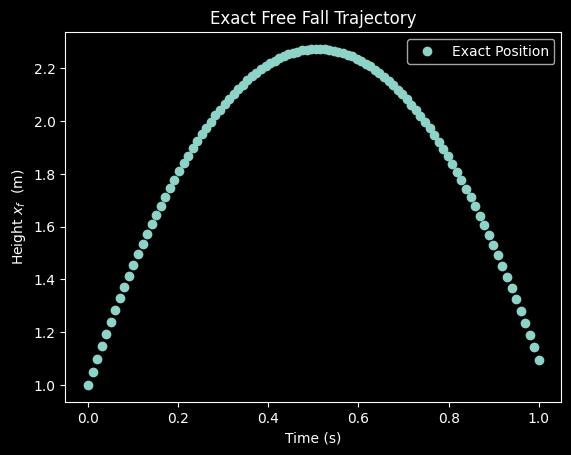

In [23]:
# 1 contd.

u = 5 # m/s
g = -9.81 # m/s^2
xi = 1 # m

def xf(t,u=5,a=-9.81,xi=1): # First equation above
    return xi + (u*t) + ((1/2)*a*t**2)


# Please note that I am starting at t = 0. Just to avoid any potential Zero Division error

t = np.linspace(0, 1,100) 

exact_vals = xf(t)
plt.plot(t, exact_vals,'o', label='Exact Position')
plt.xlabel('Time (s)')
plt.ylabel('Height $ x_f$  (m)')
plt.title('Exact Free Fall Trajectory')
plt.legend()

plt.show()




### 2. 

**Euler Method**

The Euler Method The simplest numerical approach is the Euler method. For a set of first-order differential equations, the solution at the next time step, 

$ t_{i+1}=t_{i}+h$  (1) , 


is calculated as: 

$  x_{i+1} = x_{i} + hf(t_{i},x_{i}) (2) $ 

Application: Free Fall In the case of free fall, we apply this method to update both velocity and position. Given an increment in time $ h=\Delta t$ , the update rules are: 

Position Update: 

$ x_{i+1}=x_{i}+hv_{i}$  (3)

Velocity Update: 

$ v_{i+1}=v_{i}-hg$  (4)

In  these equations, $ g$  represents the acceleration due to gravity, and $ h$  defines the step size of the simulation.


---

In [24]:
# 2.  contd. 

#??? Error, Trouble Shoot!

# We can form the above (1) equation just by using np.arrange, that adds a step of h on the start

h = 0.01 # delta t = 0.01 s
t_e_lst = np.arange(0,1,h)
xi = 1 # m
vi = 5 # m/s
g = -9.81 # m/s^2

x_e_lst = [xi] # Our Euler List
v_e_lst = [vi] # Our Euler List

for i in range(len(t_e_lst)):
    xi_next = x_e_lst[i] + (h * v_e_lst[i])
    x_e_lst.append(xi_next)
    
    vi_next = v_e_lst[i] + (h * g)
    v_e_lst.append(vi_next)
    



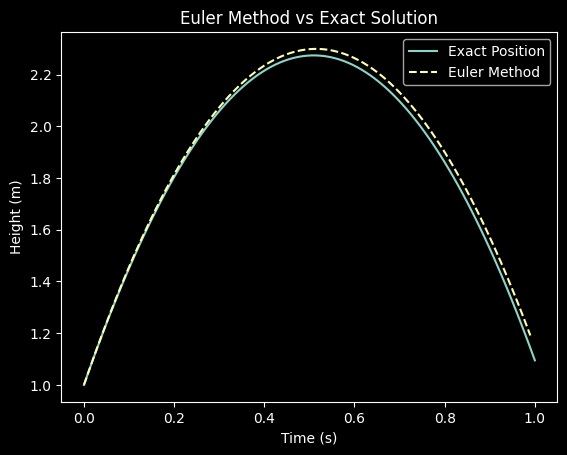

In [25]:
# 3.  

plt.plot(t, exact_vals, label='Exact Position')
plt.plot(t_e_lst, x_e_lst[:-1], '--', label='Euler Method')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Euler Method vs Exact Solution')
plt.legend()

plt.show()

**Better Methods: nth-order Runge-Kutta**

In [26]:
# 4.  
import scipy

print(scipy.integrate.solve_ivp.__doc__)

import scipy as sp
from scipy.integrate import solve_ivp


Solve an initial value problem for a system of ODEs.

    This function numerically integrates a system of ordinary differential
    equations given an initial value::

        dy / dt = f(t, y)
        y(t0) = y0

    Here t is a 1-D independent variable (time), y(t) is an
    N-D vector-valued function (state), and an N-D
    vector-valued function f(t, y) determines the differential equations.
    The goal is to find y(t) approximately satisfying the differential
    equations, given an initial value y(t0)=y0.

    Some of the solvers support integration in the complex domain, but note
    that for stiff ODE solvers, the right-hand side must be
    complex-differentiable (satisfy Cauchy-Riemann equations [11]_).
    To solve a problem in the complex domain, pass y0 with a complex data type.
    Another option always available is to rewrite your problem for real and
    imaginary parts separately.

    Parameters
    ----------
    fun : callable
        Right-hand side of the system

Note: 
The solve_ivp function from the scipy.integrate library in Python numerically solves an initial value problem (IVP) for a system of ordinary differential equations (ODEs). It works by using numerical integration methods, such as the default Dormand-Prince (RK45) Runge-Kutta method, to step through time and approximate the solution. 

> I sourced this using AI; Gemini. 
Just needed additional background

My prompt: "how to solve_ivp work?"

In [27]:
# 5.  

def free_fall_derivs(t, y):
    # y[0] is position, y[1] is velocity
    # returns [dy/dt, dv/dt]
    return [y[1], g]



In [28]:
# 6.  

x0,v0 = 1 ,5 #m , m/s
sol = solve_ivp(free_fall_derivs, [0, 1], [xi, vi])


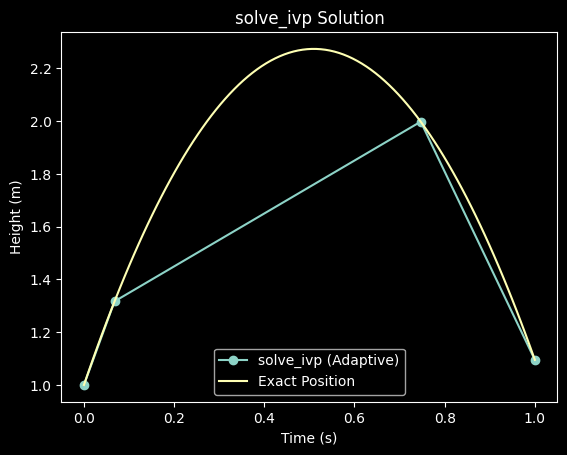

In [29]:
# 7.  

plt.plot(sol.t, sol.y[0], 'o-', label='solve_ivp (Adaptive)')
plt.plot(t, exact_vals, label='Exact Position')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('solve_ivp Solution')
plt.legend()
plt.show()

### 8. 


t_eval : array_like or None, optional
        Times at which to store the computed solution, must be sorted and lie
        within `t_span`. If None (default), use points selected by the solver.
> From the Documentation




In [30]:
t_e_lst

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])

In [31]:
#9. 

# From above Documnetation, it is clear that we can not put in a fixed step size, but give 
# the extact times. Ie, we have to use the step size ourselves and find the times.

# Please excuse me, I am going to reuse the same array I have defined before

t_e_lst

sol_steps = solve_ivp(free_fall_derivs, [0, 1], [xi, vi], 
                t_eval=t_e_lst)


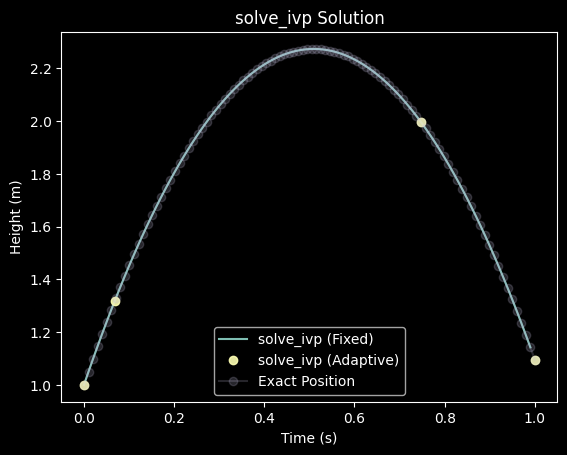

In [32]:
# 10. 

plt.plot(sol_steps.t, sol_steps.y[0], '-',alpha=0.9 ,label='solve_ivp (Fixed)')

plt.plot(sol.t, sol.y[0], 'o', alpha=0.9,label='solve_ivp (Adaptive)')
plt.plot(t, exact_vals,'o-', alpha=0.2 ,label='Exact Position')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('solve_ivp Solution')
plt.legend()
plt.show()

## Task 3: Applications

### I) Driven damped harmonic oscillator

There are many ODEs that we encounter in physics, but let’s look at the familiar one of a damped harmonic oscillator with forcing: $ m\frac{d^{2}x}{dt^{2}}+c\frac{dx}{dt}+kx=F$ Here $ m$  is the mass, $ c$  is the damping, $ k$  is the stiffness, and $ F$  is some constant external force. 

This can be rewritten as: 
$$ \frac{d^{2}x}{dt^{2}}+2\gamma \omega _{0}\frac{dx}{dt}+\omega _{0}^{2}x=f$$


where: The undamped angular frequency is $ \omega _{0}=\sqrt{k/m}$ The damping ratio is $ \gamma =\frac{c}{2\sqrt{mk}}$ The normalized force is $ f=F/m$  


### 1. 

---
Recall what the background says, 

Here $ i=1,\dots ,n$ , and we know the functions $ f_{i}$ . For example, consider Newton’s 2nd law: $ m\frac{d^{2}x}{dt^{2}}=F(t,x,v)$ where $ x$  is the position of the particle and $ F$  is the force acting on it. 

This 2nd-order differential equation can be written as two coupled 1st-order differential equations: 
$ \frac{dx}{dt}=v(t)$

$ m\frac{dv}{dt}=F(t,x,v)\quad (2)$ 

Here we track both the position $ x$  and velocity $ v$  as a function of time. For example, an object in free fall would have equations: 

$ \frac{dx}{dt}=v$, 

$ \frac{dv}{dt}=-g\quad (3)$ 

---



We get, 

(1) $ \frac{dx}{dt}=v$, 


(2) $\frac{dv}{dt} + 2\gamma \omega _{0}v + \omega _{0}^{2}x= f $

so, 
$\frac{dv}{dt} = - 2\gamma \omega _{0}v - \omega _{0}^{2}x + f $

In [33]:
# 2.  

def HO(t, y,gamma,w0,f ):
    t = t # if I put t here, down the line the functions are much easier
    x, v = y
    dx_dt = v
    dv_dt = (-2*gamma*w0*v) - (w0**2 * x) + f

    return [dx_dt,dv_dt] # THis is the derivatives of (x, v) !!
    

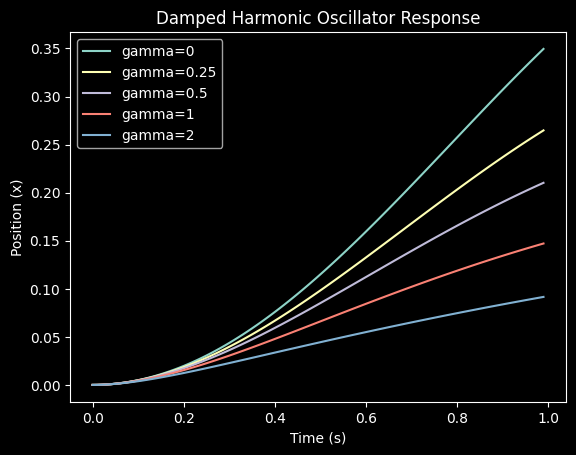

In [ ]:
# 3. 

xi = 0
vi = 0
w0 = 2
f = 1
gammas = [0, 0.25, 0.5, 1, 2]
t = [0,10]


for gamma in gammas:
        
    sol = solve_ivp(HO, t, [xi, vi],t_eval=t_e_lst,args=(gamma, w0, f))

    # The Gudie Suggested "sol = solve_ivp(your_derivs, args=(a, b, c, …), … )
    # where (a, b, c, …) are the additional parameter arguments to your derivatives function.)"

    # But If I use this syntax, I get an Error, Becase positional arguments can not come after 
    # Defined Arguments

    
    plt.plot(sol.t, sol.y[0], label=f'gamma={gamma}')


plt.xlabel('Time (s)')
plt.ylabel('Position (x)')
plt.title('Damped Harmonic Oscillator Response')
plt.legend()
plt.show()


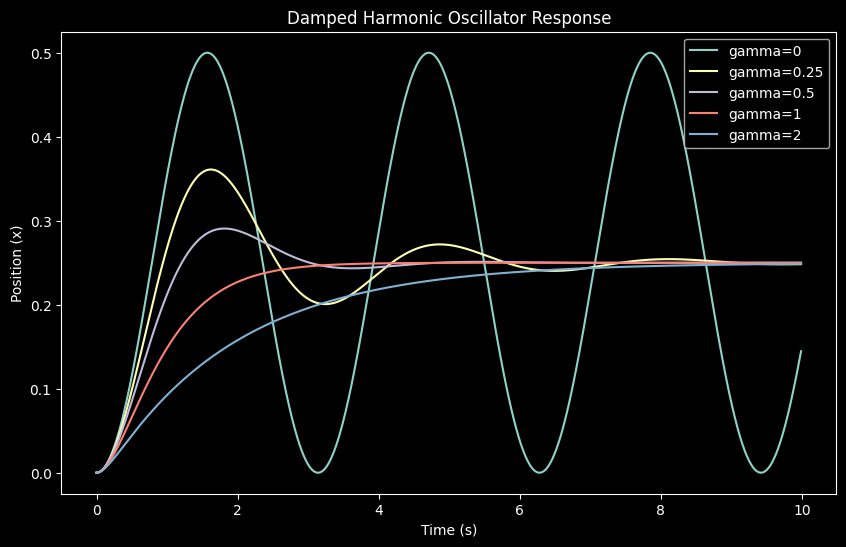

In [39]:
# 3. (AGAIN !!) and 4

# Aparentaly I need to it for a larger t values range!!

xi = 0
vi = 0
w0 = 2
f = 1
gammas = [0, 0.25, 0.5, 1, 2]

t_new_lst = np.arange(0,10,0.01)
t = [0,10]

plt.figure(figsize=(10, 6))
for gamma in gammas:
        
    sol = solve_ivp(HO, t, [xi, vi],t_eval=t_new_lst,args=(gamma, w0, f))

    # The Gudie Suggested "sol = solve_ivp(your_derivs, args=(a, b, c, …), … )
    # where (a, b, c, …) are the additional parameter arguments to your derivatives function.)"

    # But If I use this syntax, I get an Error, Becase positional arguments can not come after 
    # Defined Arguments

    
    plt.plot(sol.t, sol.y[0], label=f'gamma={gamma}')


plt.xlabel('Time (s)')
plt.ylabel('Position (x)')
plt.title('Damped Harmonic Oscillator Response')
plt.legend()
plt.show()


Yep, thats Better

### 5. Regimes comment

(Critical Damping at exaclty gamma = 1)

Seems like gamma 2 : Over Damped

gamma 1 : Critically damped

Gamma 0.5 : UnderDamped

Gamma 0.25 : Under Damped

Gamma 0 : is Undamped

> https://en.wikipedia.org/wiki/Damping
> http://labman.phys.utk.edu/phys221core/modules/m11/damped_and_driven_oscillations.html


### Time-dependent forcing $f(t) = f \cos(\omega t)$

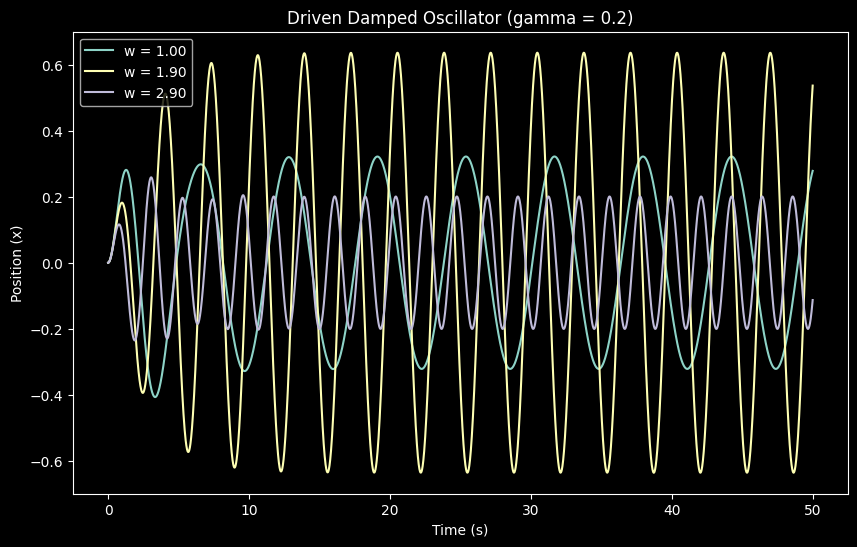

In [46]:
# 6. Time-dependent forcing f(t) = f_amp * cos(w_drive * t)

def HO_driven(t, y, gamma, w0, f, w_drive):
    x, v = y
    dx_dt = v
    external_forcing = f * np.cos(w_drive * t)
    dv_dt = (-2 * gamma * w0 * v) - (w0**2 * x) + external_forcing
    return [dx_dt, dv_dt]

gamma = 0.2
f_amp = 1
w_drives = [0.5 * w0, 0.95 * w0, 1.45 * w0]
t_span = [0, 50]  # Longer time to see steady state
t_eval_driven = np.arange(0, 50.01, 0.01)

plt.figure(figsize=(10, 6))
for w_d in w_drives:
    sol = solve_ivp(HO_driven, t_span, [0, 0], t_eval=t_eval_driven, 
                    args=(gamma, w0, f_amp, w_d))
    plt.plot(sol.t, sol.y[0], label=f'w = {w_d:.2f}')

plt.xlabel('Time (s)')
plt.ylabel('Position (x)')
plt.title('Driven Damped Oscillator (gamma = 0.2)')
plt.legend()
plt.show()

ANS: Near resonance (w = 0.95w0) (w = 1.90), the amplitude is much larger and we see beats during the transient phase. Away from resonance (w = 0.5w0 that is w = 1 or 1.45w0 , w = 2.90), the steady-state amplitude is smaller.

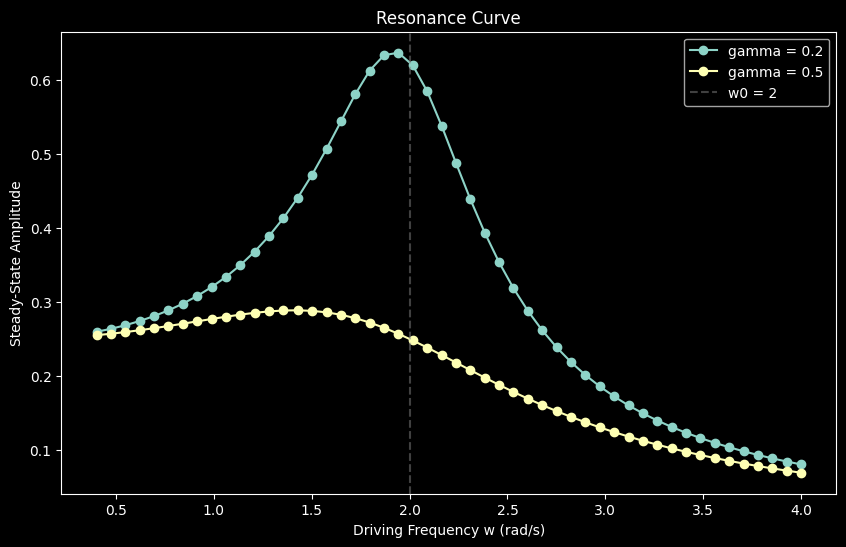

In [77]:
# 7. 

# I kept making errors for this one, I used Gemini to understand the QUestion better and help me plot this question
# My Prompt was my old Code, and the assistance I got was to not plot amplitude and time as I was doing before, and ways
# to get better visual results



w0 = 2
f_amp = 1
omega_range = np.linspace(0.2 * w0, 2.0 * w0, 50)
gammas_res = [0.2, 0.5]
t_eval_res = np.arange(0, 100.01, 0.01)

plt.figure(figsize=(10, 6))
for gamma in gammas_res:
    amplitudes = []
    for w_d in omega_range:
        sol = solve_ivp(HO_driven, [0, 100], [0, 0], t_eval=t_eval_res,
                        args=(gamma, w0, f_amp, w_d))
        
        # Taking thee last 30% to get steady state
        last_idx = int(len(sol.y[0]) * 0.7)
        amp = (np.max(sol.y[0][last_idx:]) - np.min(sol.y[0][last_idx:])) / 2
        amplitudes.append(amp)
    
    plt.plot(omega_range, amplitudes, 'o-', label=f'gamma = {gamma}')

plt.axvline(w0, color='gray', linestyle='--', alpha=0.5, label=f'w0 = {w0}')
plt.xlabel('Driving Frequency w (rad/s)')
plt.ylabel('Steady-State Amplitude')
plt.title('Resonance Curve')
plt.legend()
plt.show()

THis is somehting we saw often in Phys 233 Waves and Vibration, also in upper level physics labs. 

As the damping ratio gamma increases, the resonance peak becomes lower and broader. Higher damping dissipates more energy, reducing the maximum amplitude at resonance. This is characterized by the quality factor Q = 1/(2gamma); lower Q means broader, shorter peaks.

### II) Intro to Chaos

8. Notes:

We are given, 
$$
\frac{dx}{dt} = s(y-x) \\
\frac{dy}{dt} = rx - y - xz \\
\frac{dz}{dt} = xy - bz
$$
Parameters: $s=10, b=8/3$. Chaos for $r > 24.7$
WE must solve the ODE in t = 0 to t = 8 Δ𝑡 = 0.01 and for initial conditions: (-10, 0, 0), (10, 0, 0), and (10, 5, 0).

Our function must take in dt, inital condition list (x,y,z), s,r,b, 


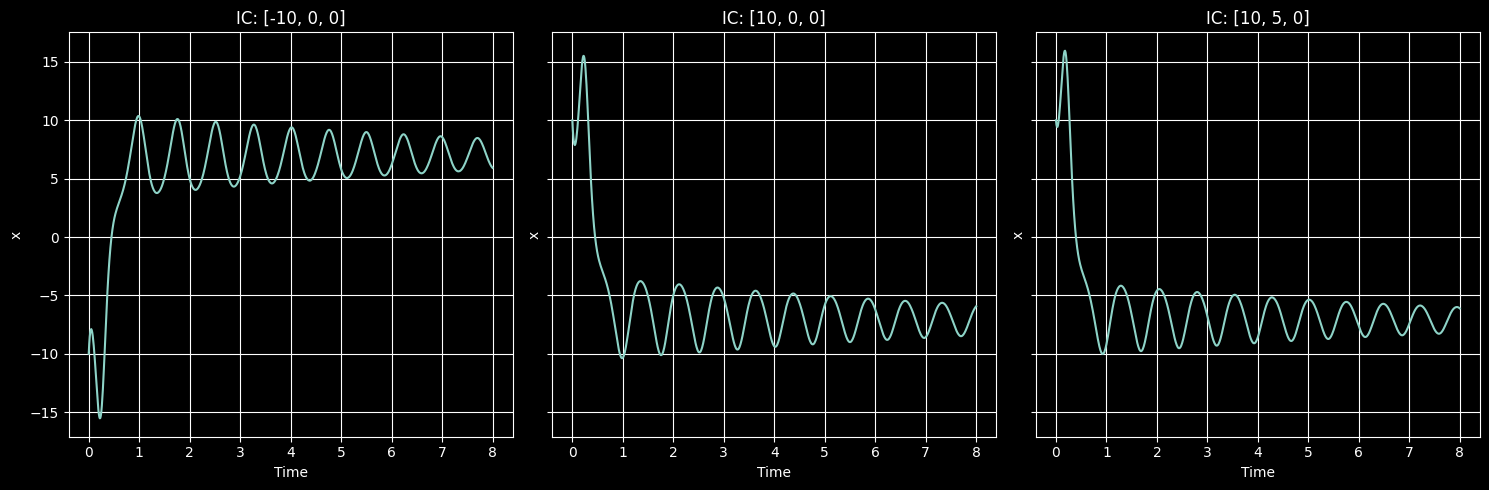

In [60]:
# 'state' is the current [x, y, z] provided by the solver at each time step
def lorenz_system(t, state, s, r, b):
    x, y, z = state  # Unpack the current state, NOT the initial conditions
    dx_dt = s * (y - x)
    dy_dt = (r * x) - y - (x * z)
    dz_dt = (x * y) - (b * z)
    return [dx_dt, dy_dt, dz_dt]

# Parameters
s = 10
b = 8/3
r_non_chaotic = 20
initial_conditions = [[-10, 0, 0], [10, 0, 0], [10, 5, 0]]
t_span = [0, 8]
t_eval = np.arange(0, 8.01, 0.01)

fig, axes = plt.subplots(1, 3, figsize=(15, 5),sharey=True)

for i, ic in enumerate(initial_conditions):
    # args must match (s, r, b) order in the function definition
    sol = solve_ivp(lorenz_system, t_span, ic, t_eval=t_eval, args=(s, r_non_chaotic, b))
    
    axes[i].plot(sol.t, sol.y[0]) 
    axes[i].set_title(f'IC: {ic}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('x')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


**ANS:** Seems like there are two attractors or settling points, one at about +6 and the at -6. 

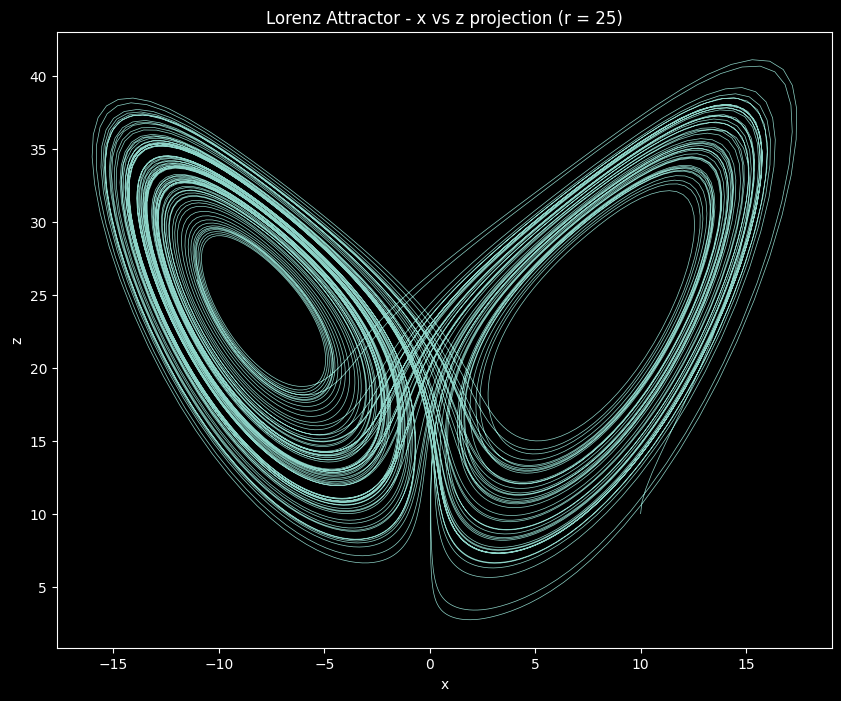

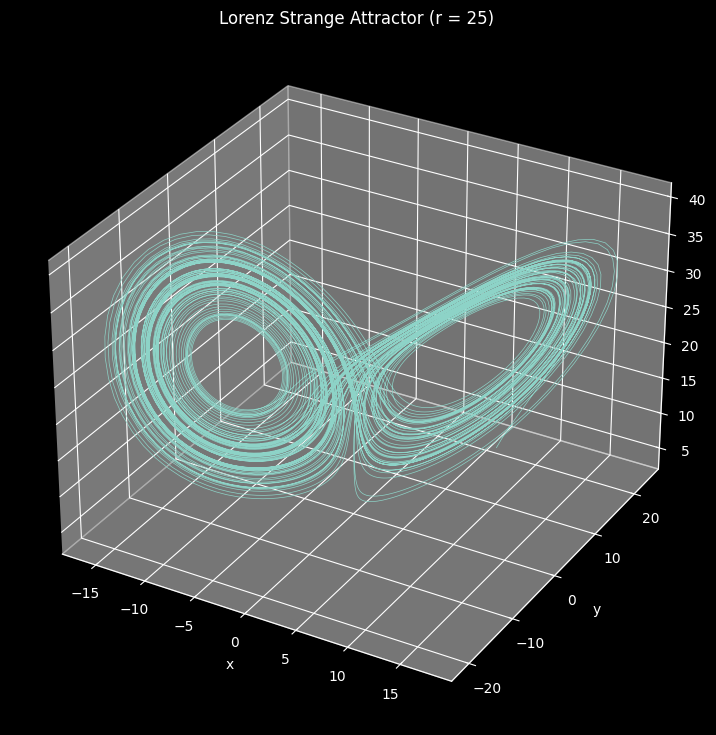

In [75]:
# 9.  

# FOr Chaotic

# Parameters
s = 10
b = 8/3
r_chaotic = 25
initial_conditions = [[-10, 0, 0], [10, 0, 0], [10, 5, 0]]
t_span = [0, 110]
t_eval = np.arange(0, 100.1, 0.01)


from mpl_toolkits.mplot3d import Axes3D


sol = solve_ivp(lorenz_system, t_span, [10, 10, 10], t_eval=t_eval, 
                args=(s, r_chaotic, b))

# 2D projection (x vs z)
plt.figure(figsize=(10, 8))
plt.plot(sol.y[0], sol.y[2], lw=0.5)
plt.xlabel('x')
plt.ylabel('z')
plt.title(f'Lorenz Attractor - x vs z projection (r = {r_chaotic})')
plt.show()

# 3D Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(f'Lorenz Strange Attractor (r = {r_chaotic})')
plt.show()



## Task 4: Wrap up

### 1. Feedback on questions
This guide was nice and well-structured

### 2. Other comments
I am very happy I saw the Lorenz diagram, Ive seen it so often online, finnally know more about it